# 🛒 Amazon India Sales — EDA
### E-Commerce Company's Path to Sustainable Growth

---
**Dataset:** Amazon India Fashion Sales | **Period:** Mar–Jun 2022

### Table of Contents
1. [Import Libraries](#s1)
2. [Load Data](#s2)
3. [Understand the Data](#s3)
   - shape, head, tail, info, dtypes, describe
4. [Data Cleaning](#s4)
   - Nulls, Duplicates, Fix columns
5. [Exploratory Data Analysis](#s5)
   - Financial Performance
   - Customer Insights
   - Logistics & Fulfilment
   - Product & Inventory
   - Customer Satisfaction & Returns
6. [Conclusion & Recommendations](#s6)

## 1. Import Libraries <a id='s1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import openpyxl
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titleweight'] = 'bold'

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Data <a id='s2'></a>

In [2]:
df = pd.read_excel(r'c:\Users\tharu\Downloads\sales_dataset(2).xlsx')
print('Dataset loaded successfully!')

Dataset loaded successfully!


## 3. Understand the Data <a id='s3'></a>

Before doing any analysis, we first need to **understand what we are working with**.

### 3.1 Shape — How many rows and columns?

In [3]:
print('Shape of the dataset:')
print(df.shape)
print(f'\nThe dataset has {df.shape[0]:,} rows and {df.shape[1]} columns.')

Shape of the dataset:
(128949, 23)

The dataset has 128,949 rows and 23 columns.


### 3.2 Head — First 5 rows

In [4]:
df.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,171-7326790-9044369,2022-03-31,Shipped,Amazon,Amazon.in,Expedited,JNE3614,JNE3614-KR-L,kurta,L,...,INR,453.00,ARANI TIRUVANNAMALAI DISTRICT,TAMIL NADU,632317.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
1,171-7326790-9044369,2022-03-31,Shipped,Amazon,Amazon.in,Expedited,JNE3294,JNE3294-KR-L,kurta,L,...,INR,353.00,ARANI TIRUVANNAMALAI DISTRICT,TAMIL NADU,632317.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
2,171-7192082-3049169,2022-03-31,Cancelled,Merchant,Amazon.in,Standard,JNE3461,JNE3461-KR-L,kurta,L,...,INR,360.95,ARANI TIRUVANNAMALAI DISTRICT,TAMIL NADU,632317.0,IN,NaN,False,Easy Ship,NaN
3,402-9467302-4929937,2022-03-31,Shipped,Amazon,Amazon.in,Expedited,JNE3405,JNE3405-KR-XXXL,kurta,3XL,...,INR,449.00,PANCHKULA,HARYANA,134116.0,IN,NaN,False,NaN,NaN
4,405-1392423-9557138,2022-03-31,Shipped,Amazon,Amazon.in,Expedited,JNE3068,JNE3068-KR-A-L,kurta,L,...,INR,688.00,Tirupati,ANDHRA PRADESH,517501.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN


### 3.3 Tail — Last 5 rows

In [5]:
df.tail()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
128944,408-0472466-5739504,2022-06-29,Shipped,Amazon,Amazon.in,Expedited,SET329,SET329-KR-NP-XXL,Set,XXL,...,INR,666.0,NAGAON,ASSAM,782138.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,0.0
128945,408-7402152-7886728,2022-06-29,Shipped,Amazon,Amazon.in,Expedited,J0225,J0225-SKD-S,Set,S,...,INR,1284.0,GURUGRAM,HARYANA,122003.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,0.0
128946,408-7402152-7886728,2022-06-29,Shipped,Amazon,Amazon.in,Expedited,J0225,J0225-SKD-XXL,Set,XXL,...,INR,1284.0,GURUGRAM,HARYANA,122003.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,0.0
128947,404-9159539-4205957,2022-06-29,Shipped,Amazon,Amazon.in,Expedited,MEN5004,MEN5004-KR-XL,kurta,XL,...,INR,709.0,AHMEDABAD,Gujarat,380058.0,IN,NaN,False,NaN,0.0
128948,408-6909744-3456308,2022-06-29,Shipped,Amazon,Amazon.in,Expedited,J0332,J0332-DR-XXL,Western Dress,XXL,...,INR,668.0,Hyderabad,TELANGANA,500090.0,IN,NaN,False,NaN,0.0


### 3.4 Columns — Column names

In [6]:
print('Column names:')
print(df.columns.tolist())

Column names:
['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']


### 3.5 Data Types — What type is each column?

In [7]:
print('Data types of each column:')
print(df.dtypes)

Data types of each column:
Order ID                      object
Date                  datetime64[ns]
Status                        object
Fulfilment                    object
Sales Channel                 object
ship-service-level            object
Style                         object
SKU                           object
Category                      object
Size                          object
ASIN                          object
Courier Status                object
Qty                            int64
currency                      object
Amount                       float64
ship-city                     object
ship-state                    object
ship-postal-code             float64
ship-country                  object
promotion-ids                 object
B2B                             bool
fulfilled-by                  object
Unnamed: 22                  float64
dtype: object


### 3.6 Info — Summary of the dataframe

`info()` shows column names, non-null counts, and dtypes all at once.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128949 entries, 0 to 128948
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order ID            128949 non-null  object        
 1   Date                128949 non-null  datetime64[ns]
 2   Status              128949 non-null  object        
 3   Fulfilment          128949 non-null  object        
 4   Sales Channel       128949 non-null  object        
 5   ship-service-level  128949 non-null  object        
 6   Style               128949 non-null  object        
 7   SKU                 128949 non-null  object        
 8   Category            128949 non-null  object        
 9   Size                128949 non-null  object        
 10  ASIN                128949 non-null  object        
 11  Courier Status      122078 non-null  object        
 12  Qty                 128949 non-null  int64         
 13  currency            121155 no

### 3.7 Describe — Statistical Summary

`describe()` gives count, mean, std, min, max and percentiles for numeric columns.

In [9]:
# Numerical columns
print('Numerical summary:')
df.describe()

Numerical summary:


,Date,Qty,Amount,ship-postal-code,Unnamed: 22
count,128949,128949.000000,121155.000000,128916.000000,79908.0
mean,2022-05-12 11:46:37.636275200,0.904629,648.550806,463978.298008,0.0
min,2022-03-31 00:00:00,0.000000,0.000000,110001.000000,0.0
25%,2022-04-20 00:00:00,1.000000,449.000000,382421.000000,0.0
50%,2022-05-10 00:00:00,1.000000,605.000000,500033.000000,0.0
75%,2022-06-04 00:00:00,1.000000,788.000000,600024.000000,0.0
max,2022-06-29 00:00:00,15.000000,5584.000000,989898.000000,0.0
std,NaN,0.314782,281.218324,191473.322953,0.0


In [10]:
# Categorical columns
print('Categorical summary:')
df.describe(include='object')

Categorical summary:


,Order ID,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,currency,ship-city,ship-state,ship-country,promotion-ids,fulfilled-by
count,128949,128949,128949,128949,128949,128949,128949,128949,128949,128949,122078,121155,128916,128916,128916,79807,39270
unique,120352,13,2,2,2,1377,7195,9,11,7190,3,1,8955,69,1,5787,1
top,171-5057375-2831560,Shipped,Amazon,Amazon.in,Expedited,JNE3797,JNE3797-KR-L,Set,M,B09SDXFFQ1,Shipped,INR,BENGALURU,MAHARASHTRA,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,Easy Ship
freq,12,77767,89679,128825,88596,4224,773,50275,22705,773,109463,121155,11212,22257,128916,46092,39270


### 3.8 Value Counts — Unique values in key columns

In [11]:
print('--- Status ---')
print(df['Status'].value_counts())

print('\n--- Category ---')
print(df['Category'].value_counts())

print('\n--- Fulfilment ---')
print(df['Fulfilment'].value_counts())

print('\n--- Sales Channel ---')
print(df['Sales Channel'].value_counts())

print('\n--- ship-service-level ---')
print(df['ship-service-level'].value_counts())

print('\n--- Size ---')
print(df['Size'].value_counts())

print('\n--- B2B ---')
print(df['B2B'].value_counts())

--- Status ---
Status
Shipped                          77767
Shipped - Delivered to Buyer     28771
Cancelled                        18341
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

--- Category ---
Category
Set              50275
kurta            49867
Western Dress    15495
Top              10621
Ethnic Dress      1158
Blouse             926
Bottom             440
Saree              164
Dupatta              3
Name: count, dtype: int64

--- Fulfilment ---
Fulfilment
Amazon      89679
Merchant    39270
Name: count, dtype: int64

--- Sales Channel ---
Sales Channel
Amazon.in     128825
Non-Amazon       124
Name: count, 

### 3.9 Date Range — What time period does the data cover?

In [12]:
df['Date'] = pd.to_datetime(df['Date'])

print(f'Start date : {df["Date"].min().date()}')
print(f'End date   : {df["Date"].max().date()}')
print(f'Total days : {(df["Date"].max() - df["Date"].min()).days}')

Start date : 2022-03-31
End date   : 2022-06-29
Total days : 90


## 4. Data Cleaning <a id='s4'></a>

Now that we understand the data, we clean it before analysis.

### 4.1 Check for Null / Missing Values

In [13]:
print('Null count per column:')
print(df.isnull().sum())

print('\nNull percentage per column:')
print((df.isnull().sum() / len(df) * 100).round(2))

Null count per column:
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6871
Qty                       0
currency               7794
Amount                 7794
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49142
B2B                       0
fulfilled-by          89679
Unnamed: 22           49041
dtype: int64

Null percentage per column:
Order ID               0.00
Date                   0.00
Status                 0.00
Fulfilment             0.00
Sales Channel          0.00
ship-service-level     0.00
Style                  0.00
SKU                    0.00
Category               0.00
Size                   0.00
ASIN       

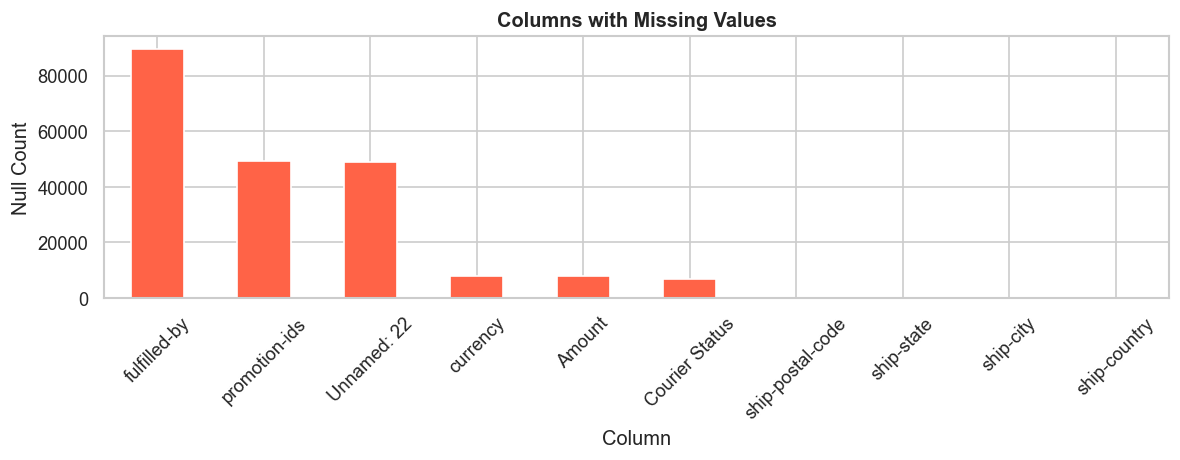

In [14]:
# Visualise nulls
null_data = df.isnull().sum()
null_data = null_data[null_data > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 4))
null_data.plot(kind='bar', color='tomato', edgecolor='white')
plt.title('Columns with Missing Values')
plt.xlabel('Column')
plt.ylabel('Null Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.2 Check for Duplicate Rows

In [15]:
print(f'Number of duplicate rows: {df.duplicated().sum()}')

# Remove duplicates
df.drop_duplicates(inplace=True)
print(f'Shape after removing duplicates: {df.shape}')

Number of duplicate rows: 6
Shape after removing duplicates: (128943, 23)


### 4.3 Handle Missing Values

- `Amount`: Replace nulls with **median** (as specified in the problem statement) by putting Amount = 0 where Status is Cancelled
- `Unnamed: 22`: Drop — fully empty column
- Other columns: Leave as-is (not used in core analysis)

In [16]:
# Step 1: Set Amount = 0 where Status is Cancelled
df.loc[df["Status"] == "Cancelled", "Amount"] = 0
print(f"Cancelled orders with Amount set to 0: {(df["Status"] == "Cancelled").sum()}")

# Step 2: Compute median AFTER zeroing cancelled (excludes NaN rows)
median_amount = df["Amount"].median()
print(f"Median Amount (after zeroing cancelled): ₹{median_amount}")

# Step 3: Fill remaining NaN values with median
df["Amount"].fillna(median_amount, inplace=True)
print(f"Null values in Amount after filling: {df["Amount"].isnull().sum()}")

# Drop useless column
df.drop(columns=["Unnamed: 22"], inplace=True, errors="ignore")
print("Dropped: Unnamed: 22")

print(f"Final shape: {df.shape}")

Cancelled orders with Amount set to 0: 18338
Median Amount (after zeroing cancelled): ₹545.0
Null values in Amount after filling: 0
Dropped: Unnamed: 22
Final shape: (128943, 22)


### 4.4 Feature Engineering — Add Useful Columns for Analysis

In [17]:
# Month and day columns
df['Month']    = df['Date'].dt.strftime('%b')          # Apr, May...
df['Month_Num']= df['Date'].dt.month
df['Day_Name'] = df['Date'].dt.day_name()              # Monday, Tuesday...

# Standardise state name
df['ship-state'] = df['ship-state'].str.upper().str.strip()

print('New columns added: Month, Month_Num, Day_Name')
print(df[['Date','Month','Day_Name']].head())

New columns added: Month, Month_Num, Day_Name
        Date Month  Day_Name
0 2022-03-31   Mar  Thursday
1 2022-03-31   Mar  Thursday
2 2022-03-31   Mar  Thursday
3 2022-03-31   Mar  Thursday
4 2022-03-31   Mar  Thursday


### 4.5 Final Data Check After Cleaning

In [18]:
print('Shape     :', df.shape)
print('Nulls left:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
df.head()

Shape     : (128943, 25)
Nulls left: 153606
Duplicates: 0


,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Month,Month_Num,Day_Name
0,171-7326790-9044369,2022-03-31,Shipped,Amazon,Amazon.in,Expedited,JNE3614,JNE3614-KR-L,kurta,L,...,ARANI TIRUVANNAMALAI DISTRICT,TAMIL NADU,632317.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,Mar,3,Thursday
1,171-7326790-9044369,2022-03-31,Shipped,Amazon,Amazon.in,Expedited,JNE3294,JNE3294-KR-L,kurta,L,...,ARANI TIRUVANNAMALAI DISTRICT,TAMIL NADU,632317.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,Mar,3,Thursday
2,171-7192082-3049169,2022-03-31,Cancelled,Merchant,Amazon.in,Standard,JNE3461,JNE3461-KR-L,kurta,L,...,ARANI TIRUVANNAMALAI DISTRICT,TAMIL NADU,632317.0,IN,NaN,False,Easy Ship,Mar,3,Thursday
3,402-9467302-4929937,2022-03-31,Shipped,Amazon,Amazon.in,Expedited,JNE3405,JNE3405-KR-XXXL,kurta,3XL,...,PANCHKULA,HARYANA,134116.0,IN,NaN,False,NaN,Mar,3,Thursday
4,405-1392423-9557138,2022-03-31,Shipped,Amazon,Amazon.in,Expedited,JNE3068,JNE3068-KR-A-L,kurta,L,...,Tirupati,ANDHRA PRADESH,517501.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,Mar,3,Thursday


## 5. Exploratory Data Analysis <a id='s5'></a>

We analyse across the 5 key challenge areas from the problem statement.

### 5A. Financial Performance
> Analyze revenue growth over time, best-selling products, and average order value.

In [19]:
# Monthly revenue and orders
MONTH_ORDER = df.sort_values('Month_Num')['Month'].unique().tolist()

monthly = df.groupby('Month').agg(
    Total_Orders  = ('Order ID', 'count'),
    Total_Revenue = ('Amount',   'sum'),
    Avg_Order_Val = ('Amount',   'mean')
).reindex(MONTH_ORDER).reset_index()

monthly['Total_Revenue'] = monthly['Total_Revenue'].round(2)
monthly['Avg_Order_Val'] = monthly['Avg_Order_Val'].round(2)

# Display only — TOTAL row not added to 'monthly' to keep charts clean
monthly_display = pd.concat([monthly, pd.DataFrame([{
    'Month'        : 'TOTAL',
    'Total_Orders' : monthly['Total_Orders'].sum(),
    'Total_Revenue': monthly['Total_Revenue'].sum().round(2),
    'Avg_Order_Val': df['Amount'].mean().round(2)
}])], ignore_index=True)

print('Monthly Revenue & Orders:')
monthly_display

Monthly Revenue & Orders:


,Month,Total_Orders,Total_Revenue,Avg_Order_Val
0,Mar,171,95355.00,557.63
1,Apr,49056,26278569.62,535.69
2,May,42032,23982071.00,570.57
3,Jun,37684,21416318.00,568.31
4,TOTAL,128943,71772313.62,556.62


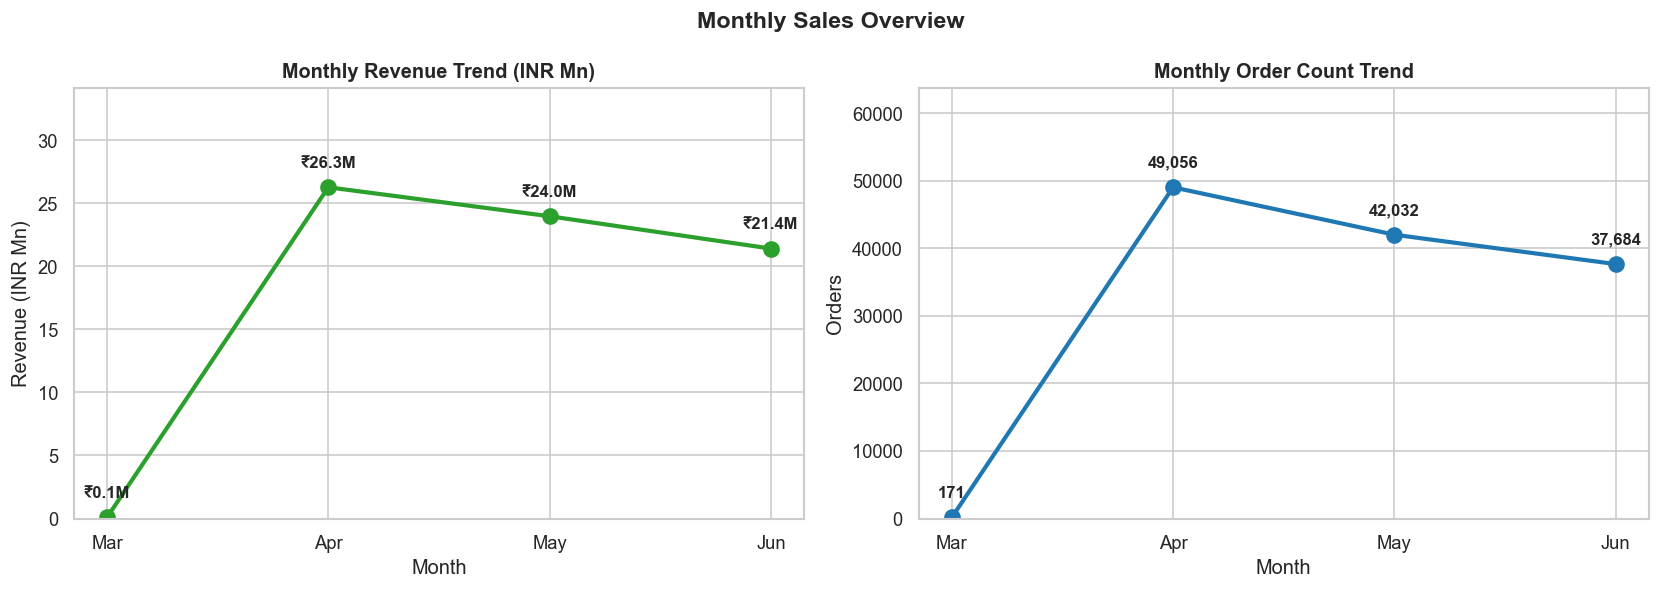

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly Revenue — line chart (trend over time)
axes[0].plot(monthly['Month'], monthly['Total_Revenue'] / 1e6,
             marker='o', linewidth=2.5, color='#2ca02c', markersize=9)
for x, y in zip(monthly['Month'], monthly['Total_Revenue'] / 1e6):
    axes[0].annotate(f'₹{y:.1f}M', (x, y), xytext=(0, 12),
                     textcoords='offset points', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Monthly Revenue Trend (INR Mn)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (INR Mn)')
axes[0].set_ylim(0, monthly['Total_Revenue'].max() / 1e6 * 1.3)

# Monthly Orders — line chart (trend over time)
axes[1].plot(monthly['Month'], monthly['Total_Orders'],
             marker='o', linewidth=2.5, color='#1f77b4', markersize=9)
for x, y in zip(monthly['Month'], monthly['Total_Orders']):
    axes[1].annotate(f'{int(y):,}', (x, y), xytext=(0, 12),
                     textcoords='offset points', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Monthly Order Count Trend')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Orders')
axes[1].set_ylim(0, monthly['Total_Orders'].max() * 1.3)

plt.suptitle('Monthly Sales Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

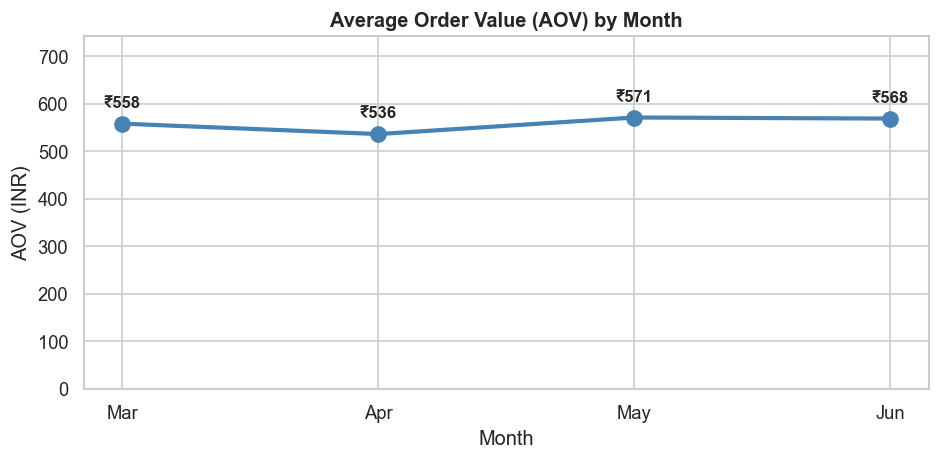

In [21]:
# Average Order Value by month
plt.figure(figsize=(8, 4))
plt.plot(monthly['Month'], monthly['Avg_Order_Val'],
         marker='o', linewidth=2.5, color='steelblue', markersize=9)
for x, y in zip(monthly['Month'], monthly['Avg_Order_Val']):
    plt.annotate(f'₹{y:.0f}', (x, y), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontsize=10, fontweight='bold')
plt.title('Average Order Value (AOV) by Month')
plt.xlabel('Month')
plt.ylabel('AOV (INR)')
plt.ylim(0, max(monthly['Avg_Order_Val']) * 1.3)
plt.tight_layout()
plt.show()

In [22]:
# Revenue by Category
cat_rev = df.groupby('Category')['Amount'].sum().sort_values(ascending=False).reset_index()
cat_rev.columns = ['Category', 'Revenue']
cat_rev['Revenue'] = cat_rev['Revenue'].round(2)

# Display only
cat_rev_display = pd.concat([cat_rev, pd.DataFrame([{
    'Category': 'TOTAL',
    'Revenue' : cat_rev['Revenue'].sum().round(2)
}])], ignore_index=True)

print('Revenue by Category:')
cat_rev_display

Revenue by Category:


,Category,Revenue
0,Set,35777485.14
1,kurta,19473274.48
2,Western Dress,10208405.00
3,Top,4908912.00
4,Ethnic Dress,732061.00
5,Blouse,420569.00
6,Bottom,135998.00
7,Saree,114694.00
8,Dupatta,915.00
9,TOTAL,71772313.62


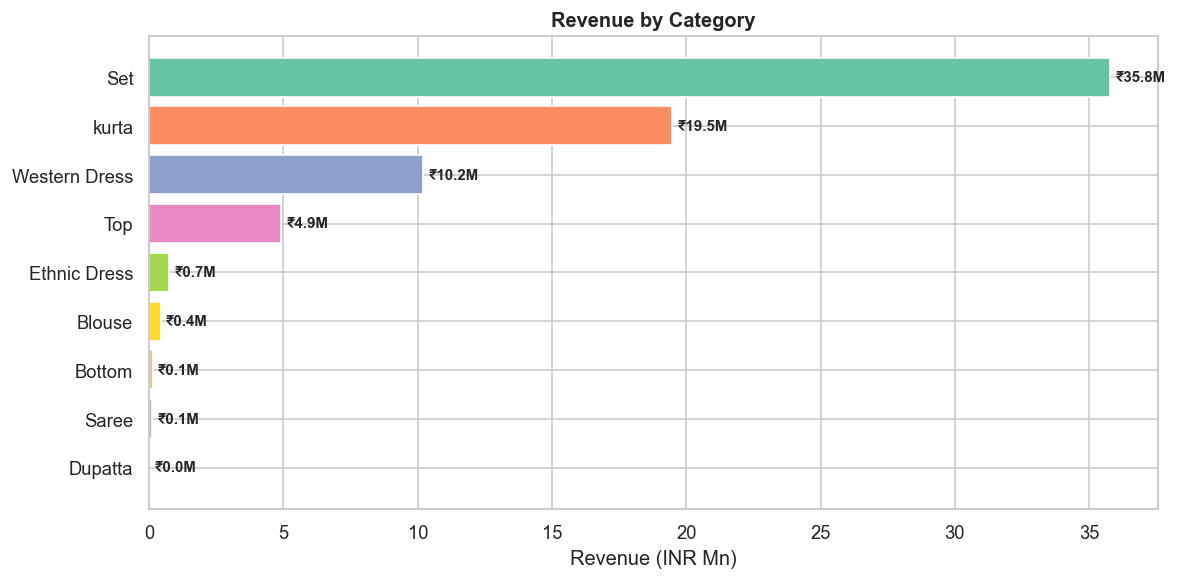

In [23]:
# Horizontal bar chart — compare revenue across categories (comparison, not trend)
plt.figure(figsize=(10, 5))
bars = plt.barh(cat_rev['Category'], cat_rev['Revenue'] / 1e6,
                color=sns.color_palette('Set2', len(cat_rev)), edgecolor='white')
for bar in bars:
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'₹{bar.get_width():.1f}M', va='center', fontsize=9, fontweight='bold')
plt.title('Revenue by Category')
plt.xlabel('Revenue (INR Mn)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [24]:
# Sales by Day of Week
DAY_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

day_sales = df.groupby('Day_Name').agg(
    Orders  = ('Order ID', 'count'),
    Revenue = ('Amount',   'sum')
).reindex(DAY_ORDER).reset_index()

day_sales['Revenue'] = day_sales['Revenue'].round(2)

# Display only
day_sales_display = pd.concat([day_sales, pd.DataFrame([{
    'Day_Name': 'TOTAL',
    'Orders'  : day_sales['Orders'].sum(),
    'Revenue' : day_sales['Revenue'].sum().round(2)
}])], ignore_index=True)

print('Sales by Day of Week:')
day_sales_display

Sales by Day of Week:


,Day_Name,Orders,Revenue
0,Monday,18560,10301495.00
1,Tuesday,18874,10489883.00
2,Wednesday,18589,10315712.00
3,Thursday,17069,9490909.00
4,Friday,17718,9861726.00
5,Saturday,18514,10302682.62
6,Sunday,19619,11009906.00
7,TOTAL,128943,71772313.62


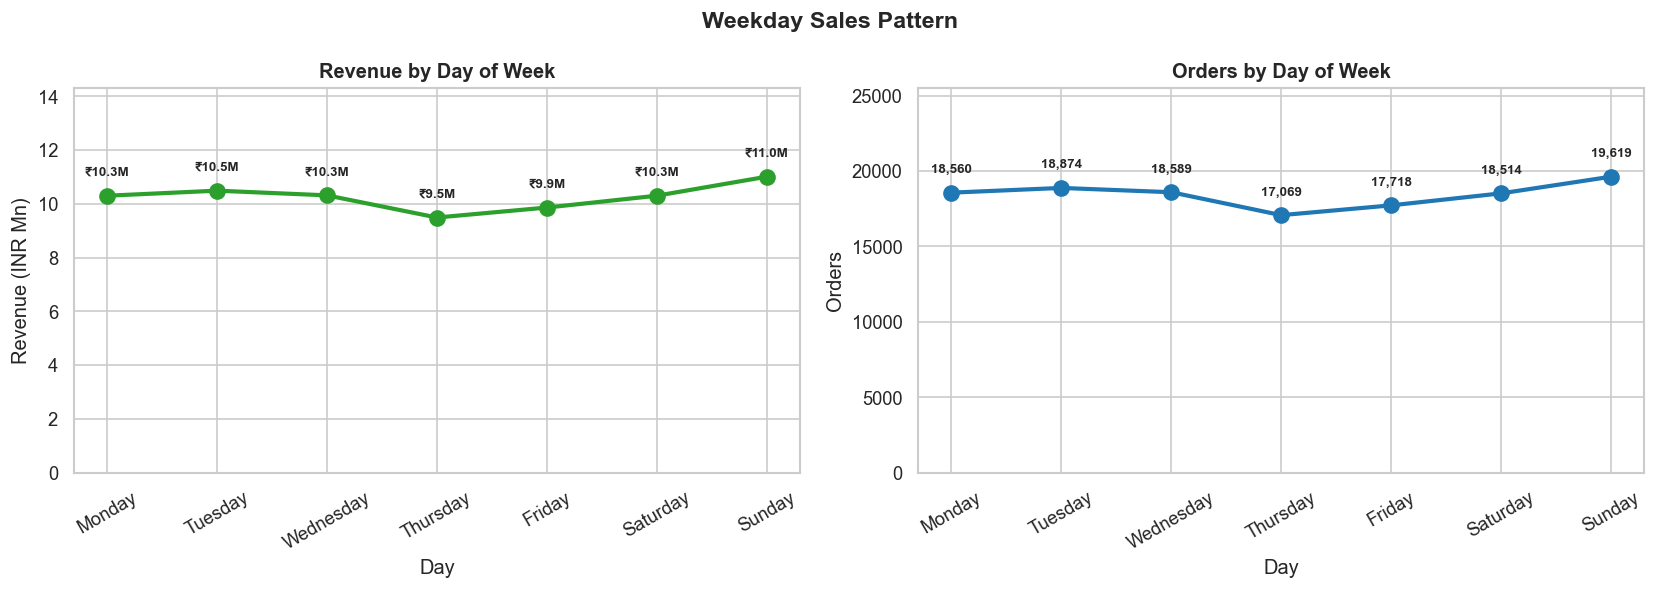

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

DAY_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_sales = day_sales.set_index('Day_Name').reindex(DAY_ORDER).reset_index()

axes[0].plot(day_sales['Day_Name'], day_sales['Revenue'] / 1e6,
             marker='o', linewidth=2.5, color='#2ca02c', markersize=9)
for x, y in zip(day_sales['Day_Name'], day_sales['Revenue'] / 1e6):
    axes[0].annotate(f'₹{y:.1f}M', (x, y), xytext=(0, 12),
                     textcoords='offset points', ha='center', fontsize=8, fontweight='bold')
axes[0].set_title('Revenue by Day of Week')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Revenue (INR Mn)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0, (day_sales['Revenue'] / 1e6).max() * 1.3)

axes[1].plot(day_sales['Day_Name'], day_sales['Orders'],
             marker='o', linewidth=2.5, color='#1f77b4', markersize=9)
for x, y in zip(day_sales['Day_Name'], day_sales['Orders']):
    axes[1].annotate(f'{int(y):,}', (x, y), xytext=(0, 12),
                     textcoords='offset points', ha='center', fontsize=8, fontweight='bold')
axes[1].set_title('Orders by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Orders')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(0, day_sales['Orders'].max() * 1.3)

plt.suptitle('Weekday Sales Pattern', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5B. Customer Insights
> Top locations, cancellation trends, B2B vs B2C.

In [26]:
# Top 10 states by orders
top_states = df['ship-state'].value_counts().head(10).reset_index()
top_states.columns = ['State', 'Orders']

# Display only
top_states_display = pd.concat([top_states, pd.DataFrame([{
    'State' : 'TOTAL (Top 10)',
    'Orders': top_states['Orders'].sum()
}])], ignore_index=True)

print('Top 10 States by Orders:')
top_states_display

Top 10 States by Orders:


,State,Orders
0,MAHARASHTRA,22256
1,KARNATAKA,17320
2,TAMIL NADU,11481
3,TELANGANA,11327
4,UTTAR PRADESH,10635
5,DELHI,6964
6,KERALA,6584
7,WEST BENGAL,5961
8,ANDHRA PRADESH,5429
9,GUJARAT,4489


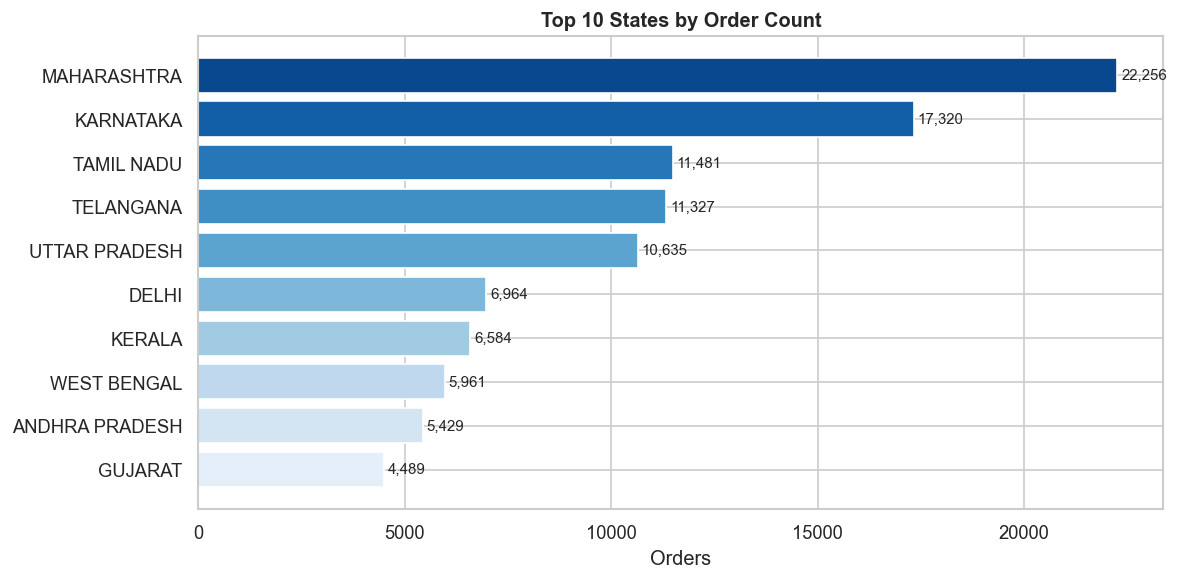

In [27]:
plt.figure(figsize=(10, 5))
bars = plt.barh(top_states['State'], top_states['Orders'],
                color=sns.color_palette('Blues_r', 10), edgecolor='white')
for bar in bars:
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width()):,}', va='center', fontsize=9)
plt.gca().invert_yaxis()
plt.title('Top 10 States by Order Count')
plt.xlabel('Orders')
plt.tight_layout()
plt.show()

In [28]:
# Order status / cancellation breakdown
status_counts = df['Status'].value_counts().reset_index()
status_counts.columns = ['Status', 'Count']
status_counts['Percentage'] = (status_counts['Count'] / len(df) * 100).round(2)

# Display only
status_display = pd.concat([status_counts, pd.DataFrame([{
    'Status'    : 'TOTAL',
    'Count'     : status_counts['Count'].sum(),
    'Percentage': 100.00
}])], ignore_index=True)

print('Order Status Breakdown:')
status_display

Order Status Breakdown:


,Status,Count,Percentage
0,Shipped,77764,60.31
1,Shipped - Delivered to Buyer,28771,22.31
2,Cancelled,18338,14.22
3,Shipped - Returned to Seller,1953,1.51
4,Shipped - Picked Up,973,0.75
5,Pending,658,0.51
6,Pending - Waiting for Pick Up,281,0.22
7,Shipped - Returning to Seller,145,0.11
8,Shipped - Out for Delivery,35,0.03
9,Shipped - Rejected by Buyer,11,0.01


In [29]:
# Monthly cancellation trend
MONTH_ORDER = df.sort_values('Month_Num')['Month'].unique().tolist()

canc = df[df['Status'] == 'Cancelled'].groupby('Month').size().reindex(MONTH_ORDER).reset_index()
canc.columns = ['Month', 'Cancellations']

total_by_month = df.groupby('Month').size().reindex(MONTH_ORDER).reset_index()
total_by_month.columns = ['Month', 'Total_Orders']

canc_trend = canc.merge(total_by_month, on='Month')
canc_trend['Cancel_Rate_%'] = (canc_trend['Cancellations'] / canc_trend['Total_Orders'] * 100).round(2)

# Display only
canc_trend_display = pd.concat([canc_trend, pd.DataFrame([{
    'Month'         : 'TOTAL',
    'Cancellations' : canc_trend['Cancellations'].sum(),
    'Total_Orders'  : canc_trend['Total_Orders'].sum(),
    'Cancel_Rate_%' : round(canc_trend['Cancellations'].sum() / canc_trend['Total_Orders'].sum() * 100, 2)
}])], ignore_index=True)

print('Monthly Cancellation Trend:')
canc_trend_display

Monthly Cancellation Trend:


,Month,Cancellations,Total_Orders,Cancel_Rate_%
0,Mar,18,171,10.53
1,Apr,7137,49056,14.55
2,May,5880,42032,13.99
3,Jun,5303,37684,14.07
4,TOTAL,18338,128943,14.22


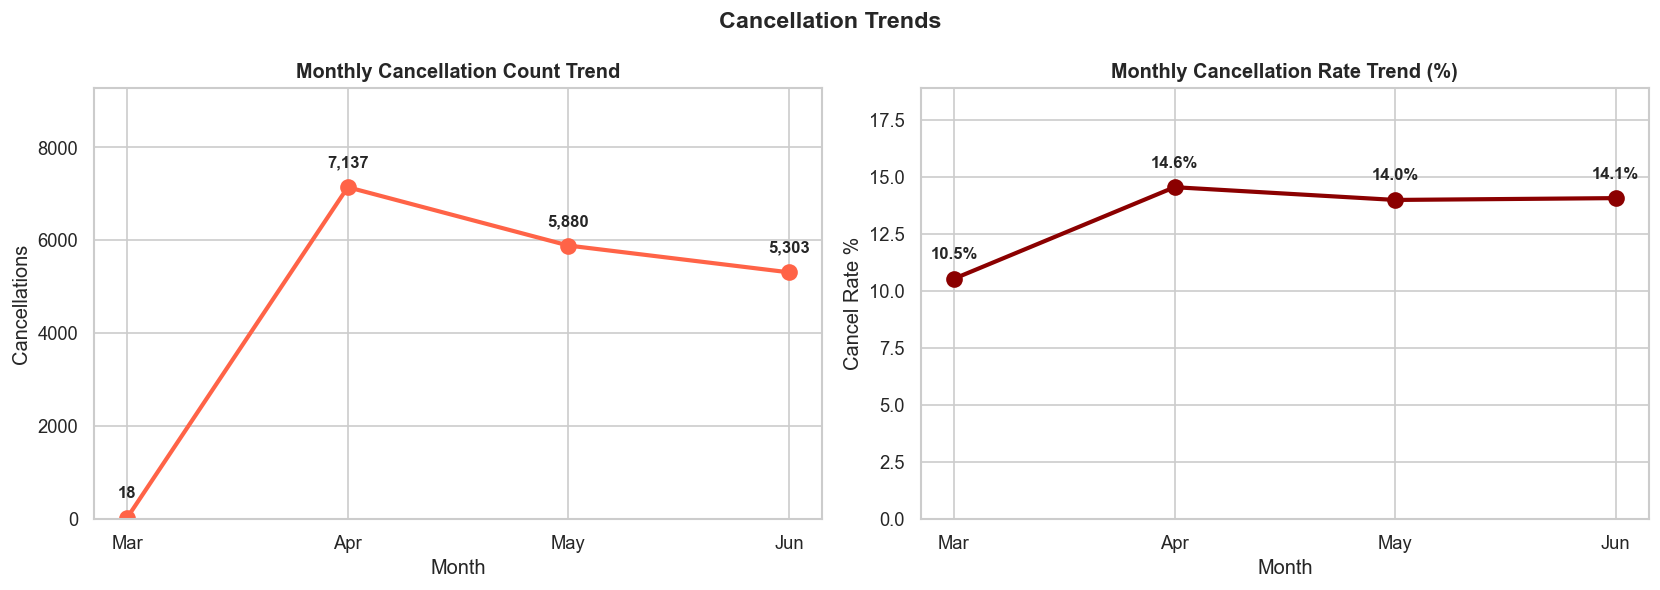

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cancellation count trend — line chart
axes[0].plot(canc_trend['Month'], canc_trend['Cancellations'],
             marker='o', linewidth=2.5, color='tomato', markersize=9)
for x, y in zip(canc_trend['Month'], canc_trend['Cancellations']):
    axes[0].annotate(f'{int(y):,}', (x, y), xytext=(0, 12),
                     textcoords='offset points', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Monthly Cancellation Count Trend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Cancellations')
axes[0].set_ylim(0, canc_trend['Cancellations'].max() * 1.3)

# Cancellation rate trend — line chart
axes[1].plot(canc_trend['Month'], canc_trend['Cancel_Rate_%'],
             marker='o', linewidth=2.5, color='darkred', markersize=9)
for x, y in zip(canc_trend['Month'], canc_trend['Cancel_Rate_%']):
    axes[1].annotate(f'{y:.1f}%', (x, y), xytext=(0, 12),
                     textcoords='offset points', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Monthly Cancellation Rate Trend (%)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Cancel Rate %')
axes[1].set_ylim(0, canc_trend['Cancel_Rate_%'].max() * 1.3)

plt.suptitle('Cancellation Trends', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# B2B vs B2C
b2b = df.groupby('B2B').agg(
    Orders    = ('Order ID', 'count'),
    Revenue   = ('Amount',   'sum'),
    Avg_Value = ('Amount',   'mean')
).reset_index()
b2b['Segment']   = b2b['B2B'].map({True: 'B2B', False: 'B2C'})
b2b['Revenue']   = b2b['Revenue'].round(2)
b2b['Avg_Value'] = b2b['Avg_Value'].round(2)
b2b = b2b[['Segment','Orders','Revenue','Avg_Value']]

# Display only
b2b_display = pd.concat([b2b, pd.DataFrame([{
    'Segment'  : 'TOTAL',
    'Orders'   : b2b['Orders'].sum(),
    'Revenue'  : b2b['Revenue'].sum().round(2),
    'Avg_Value': df['Amount'].mean().round(2)
}])], ignore_index=True)

print('B2B vs B2C Comparison:')
b2b_display

B2B vs B2C Comparison:


,Segment,Orders,Revenue,Avg_Value
0,B2C,128072,71212368.62,556.03
1,B2B,871,559945.00,642.88
2,TOTAL,128943,71772313.62,556.62


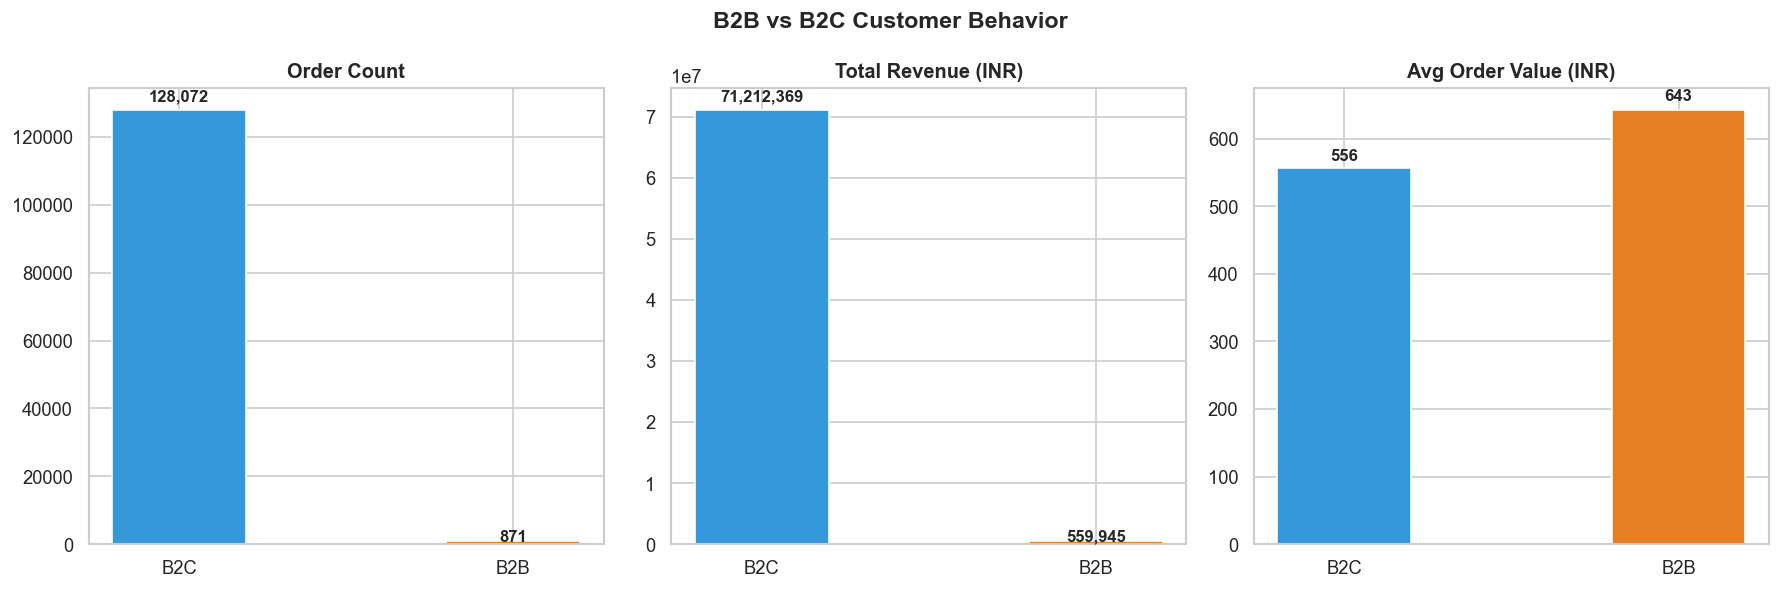

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pal_b2b = ['#3498DB', '#E67E22']

for ax, col, title in zip(
        axes,
        ['Orders', 'Revenue', 'Avg_Value'],
        ['Order Count', 'Total Revenue (INR)', 'Avg Order Value (INR)']):
    ax.bar(b2b['Segment'], b2b[col], color=pal_b2b, edgecolor='white', width=0.4)
    for bar, val in zip(ax.patches, b2b[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{val:,.0f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title)

plt.suptitle('B2B vs B2C Customer Behavior', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5C. Logistics & Fulfilment
> Compare Amazon vs Merchant fulfilment and shipping service levels.

In [33]:
# Fulfilment comparison
ful = df.groupby('Fulfilment').agg(
    Orders    = ('Order ID', 'count'),
    Revenue   = ('Amount',   'sum'),
    Avg_Value = ('Amount',   'mean')
).reset_index()
ful['Revenue']   = ful['Revenue'].round(2)
ful['Avg_Value'] = ful['Avg_Value'].round(2)

# Display only
ful_display = pd.concat([ful, pd.DataFrame([{
    'Fulfilment': 'TOTAL',
    'Orders'    : ful['Orders'].sum(),
    'Revenue'   : ful['Revenue'].sum().round(2),
    'Avg_Value' : df['Amount'].mean().round(2)
}])], ignore_index=True)

print('Fulfilment Comparison:')
ful_display

Fulfilment Comparison:


,Fulfilment,Orders,Revenue,Avg_Value
0,Amazon,89673,50690230.00,565.28
1,Merchant,39270,21082083.62,536.85
2,TOTAL,128943,71772313.62,556.62


In [34]:
# Shipping service level
svc = df.groupby('ship-service-level').agg(
    Orders  = ('Order ID', 'count'),
    Revenue = ('Amount',   'sum')
).reset_index()
svc['Revenue'] = svc['Revenue'].round(2)

# Display only
svc_display = pd.concat([svc, pd.DataFrame([{
    'ship-service-level': 'TOTAL',
    'Orders'            : svc['Orders'].sum(),
    'Revenue'           : svc['Revenue'].sum().round(2)
}])], ignore_index=True)

print('Shipping Service Level:')
svc_display

Shipping Service Level:


,ship-service-level,Orders,Revenue
0,Expedited,88590,50588589.00
1,Standard,40353,21183724.62
2,TOTAL,128943,71772313.62


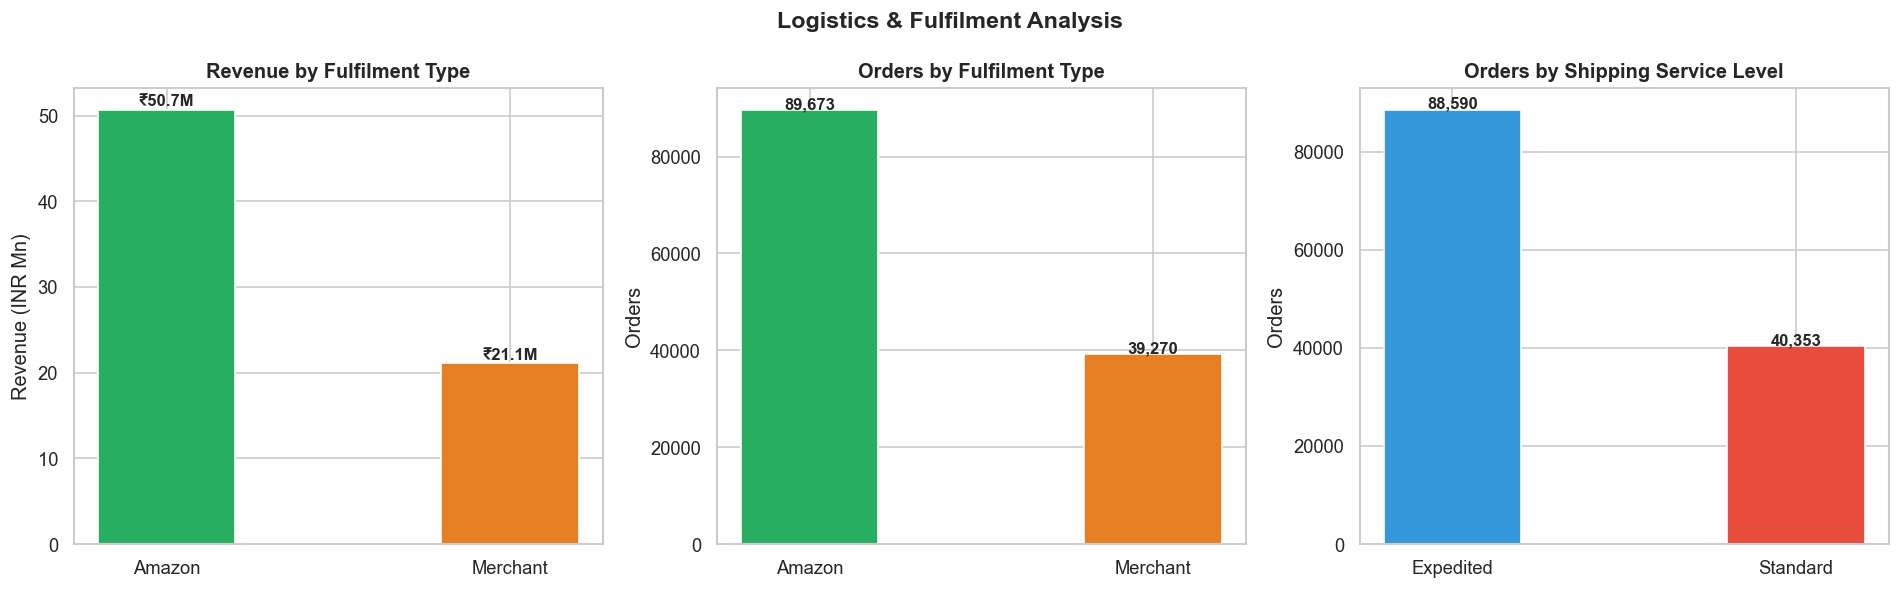

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Fulfilment revenue — bar chart (comparison between 2 categories)
axes[0].bar(ful['Fulfilment'], ful['Revenue'] / 1e6,
            color=['#27AE60', '#E67E22'], edgecolor='white', width=0.4)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'₹{bar.get_height():.1f}M', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Revenue by Fulfilment Type')
axes[0].set_ylabel('Revenue (INR Mn)')

# Fulfilment orders — bar chart
axes[1].bar(ful['Fulfilment'], ful['Orders'],
            color=['#27AE60', '#E67E22'], edgecolor='white', width=0.4)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Orders by Fulfilment Type')
axes[1].set_ylabel('Orders')

# Service level — bar chart
axes[2].bar(svc['ship-service-level'], svc['Orders'],
            color=['#3498DB', '#E74C3C'], edgecolor='white', width=0.4)
for bar in axes[2].patches:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=10, fontweight='bold')
axes[2].set_title('Orders by Shipping Service Level')
axes[2].set_ylabel('Orders')

plt.suptitle('Logistics & Fulfilment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5D. Product Management & Inventory
> High-demand categories, average quantity ordered, size distribution.

In [36]:
# Average quantity by category
qty_cat = df.groupby('Category').agg(
    Total_Orders = ('Order ID', 'count'),
    Total_Qty    = ('Qty',       'sum'),
    Avg_Qty      = ('Qty',       'mean')
).sort_values('Total_Qty', ascending=False).reset_index()
qty_cat['Avg_Qty'] = qty_cat['Avg_Qty'].round(3)

# Display only
qty_cat_display = pd.concat([qty_cat, pd.DataFrame([{
    'Category'    : 'TOTAL',
    'Total_Orders': qty_cat['Total_Orders'].sum(),
    'Total_Qty'   : qty_cat['Total_Qty'].sum(),
    'Avg_Qty'     : df['Qty'].mean().round(3)
}])], ignore_index=True)

print('Category Demand & Quantity:')
qty_cat_display

Category Demand & Quantity:


,Category,Total_Orders,Total_Qty,Avg_Qty
0,Set,50272,45286,0.901
1,kurta,49864,45048,0.903
2,Western Dress,15495,13943,0.900
3,Top,10621,9902,0.932
4,Ethnic Dress,1158,1052,0.908
5,Blouse,926,864,0.933
6,Bottom,440,398,0.905
7,Saree,164,152,0.927
8,Dupatta,3,3,1.000
9,TOTAL,128943,116648,0.905


In [37]:
# Size distribution
SIZE_ORDER = ['XS','S','M','L','XL','XXL','3XL','4XL','5XL','6XL','Free']
size_dist = df['Size'].value_counts().reindex(SIZE_ORDER).reset_index()
size_dist.columns = ['Size', 'Orders']

# Display only
size_dist_display = pd.concat([size_dist, pd.DataFrame([{
    'Size'  : 'TOTAL',
    'Orders': size_dist['Orders'].sum()
}])], ignore_index=True)

print('Size Distribution:')
size_dist_display

Size Distribution:


,Size,Orders
0,XS,11157
1,S,17092
2,M,22703
3,L,22122
4,XL,20878
5,XXL,18089
6,3XL,14810
7,4XL,426
8,5XL,550
9,6XL,737


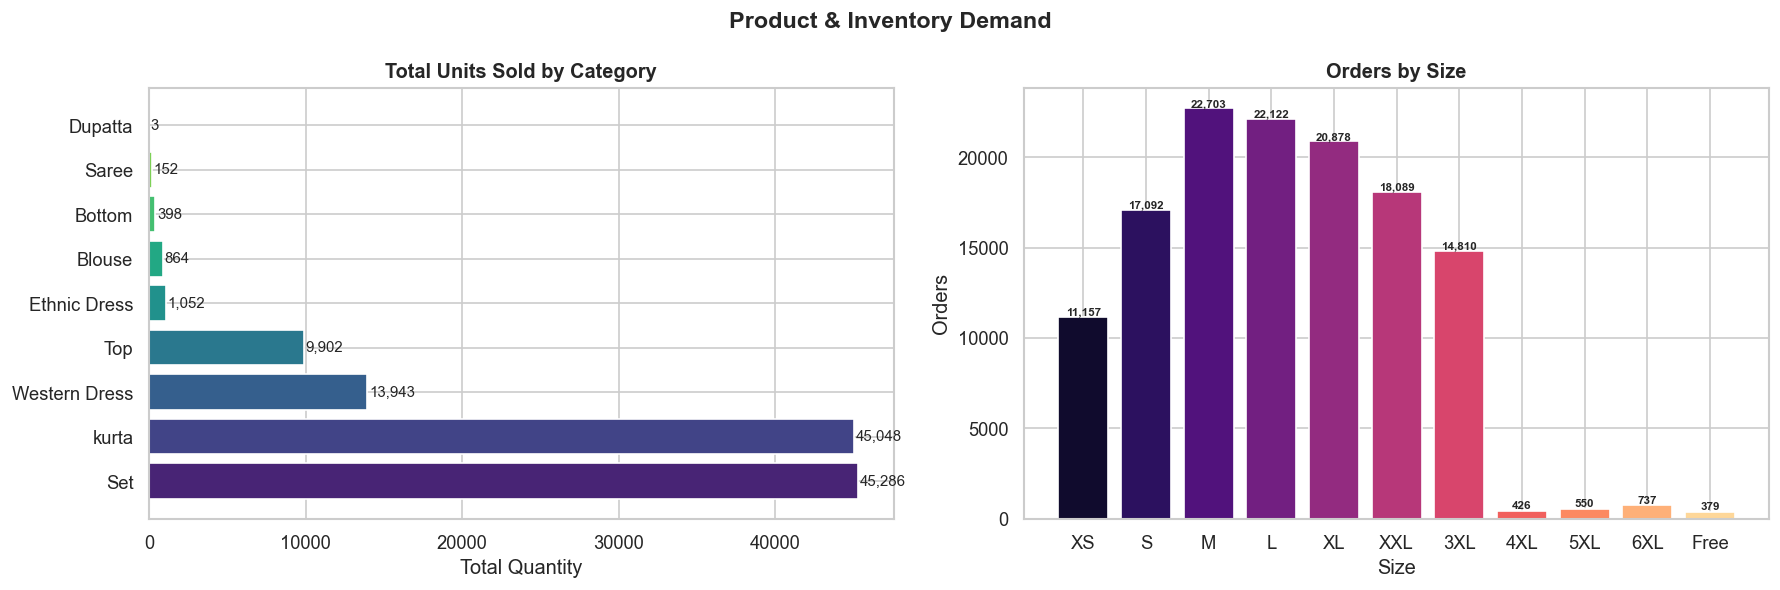

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Total Qty by Category
pal4 = sns.color_palette('viridis', len(qty_cat))
axes[0].barh(qty_cat['Category'], qty_cat['Total_Qty'],
             color=pal4, edgecolor='white')
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width()):,}', va='center', fontsize=9)
axes[0].set_title('Total Units Sold by Category')
axes[0].set_xlabel('Total Quantity')

# Size distribution
axes[1].bar(size_dist['Size'], size_dist['Orders'],
            color=sns.color_palette('magma', len(SIZE_ORDER)), edgecolor='white')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=7, fontweight='bold')
axes[1].set_title('Orders by Size')
axes[1].set_xlabel('Size')
axes[1].set_ylabel('Orders')

plt.suptitle('Product & Inventory Demand', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5E. Customer Satisfaction & Returns
> Return and cancellation rates, problematic products.

In [39]:
# Return and cancel rates
total = len(df)
cancelled = (df['Status'] == 'Cancelled').sum()
returned  = df['Status'].str.contains('Return', na=False).sum()

print(f'Total Orders   : {total:,}')
print(f'Cancelled      : {cancelled:,} ({cancelled/total*100:.2f}%)')
print(f'Returned       : {returned:,}  ({returned/total*100:.2f}%)')
print(f'Successful     : {total - cancelled - returned:,} ({(total - cancelled - returned)/total*100:.2f}%)')

Total Orders   : 128,943
Cancelled      : 18,338 (14.22%)
Returned       : 2,098  (1.63%)
Successful     : 108,507 (84.15%)


In [40]:
# Problematic orders by category (cancelled + returned)
prob = df[df['Status'].isin(['Cancelled']) | df['Status'].str.contains('Return', na=False)]

prob_cat = prob.groupby('Category').size().sort_values(ascending=False).reset_index()
prob_cat.columns = ['Category', 'Issue_Count']
prob_cat['% of Total Issues'] = (prob_cat['Issue_Count'] / len(prob) * 100).round(2)

# Display only
prob_cat_display = pd.concat([prob_cat, pd.DataFrame([{
    'Category'         : 'TOTAL',
    'Issue_Count'      : prob_cat['Issue_Count'].sum(),
    '% of Total Issues': 100.00
}])], ignore_index=True)

print('Problematic Orders by Category:')
prob_cat_display

Problematic Orders by Category:


,Category,Issue_Count,% of Total Issues
0,Set,8176,40.01
1,kurta,8007,39.18
2,Western Dress,2467,12.07
3,Top,1408,6.89
4,Ethnic Dress,162,0.79
5,Blouse,128,0.63
6,Bottom,66,0.32
7,Saree,22,0.11
8,TOTAL,20436,100.00


In [41]:
# Top 10 problematic SKUs
prob_sku = prob.groupby('SKU').size().sort_values(ascending=False).head(10).reset_index()
prob_sku.columns = ['SKU', 'Issue_Count']

# Display only
prob_sku_display = pd.concat([prob_sku, pd.DataFrame([{
    'SKU'        : 'TOTAL (Top 10)',
    'Issue_Count': prob_sku['Issue_Count'].sum()
}])], ignore_index=True)

print('Top 10 Problematic SKUs:')
prob_sku_display

Top 10 Problematic SKUs:


,SKU,Issue_Count
0,JNE3797-KR-L,152
1,JNE3797-KR-M,125
2,JNE3797-KR-S,122
3,JNE3405-KR-L,88
4,JNE3797-KR-XL,85
5,JNE3797-KR-XS,76
6,JNE3405-KR-M,76
7,J0230-SKD-M,75
8,J0003-SET-S,74
9,J0003-SET-M,72


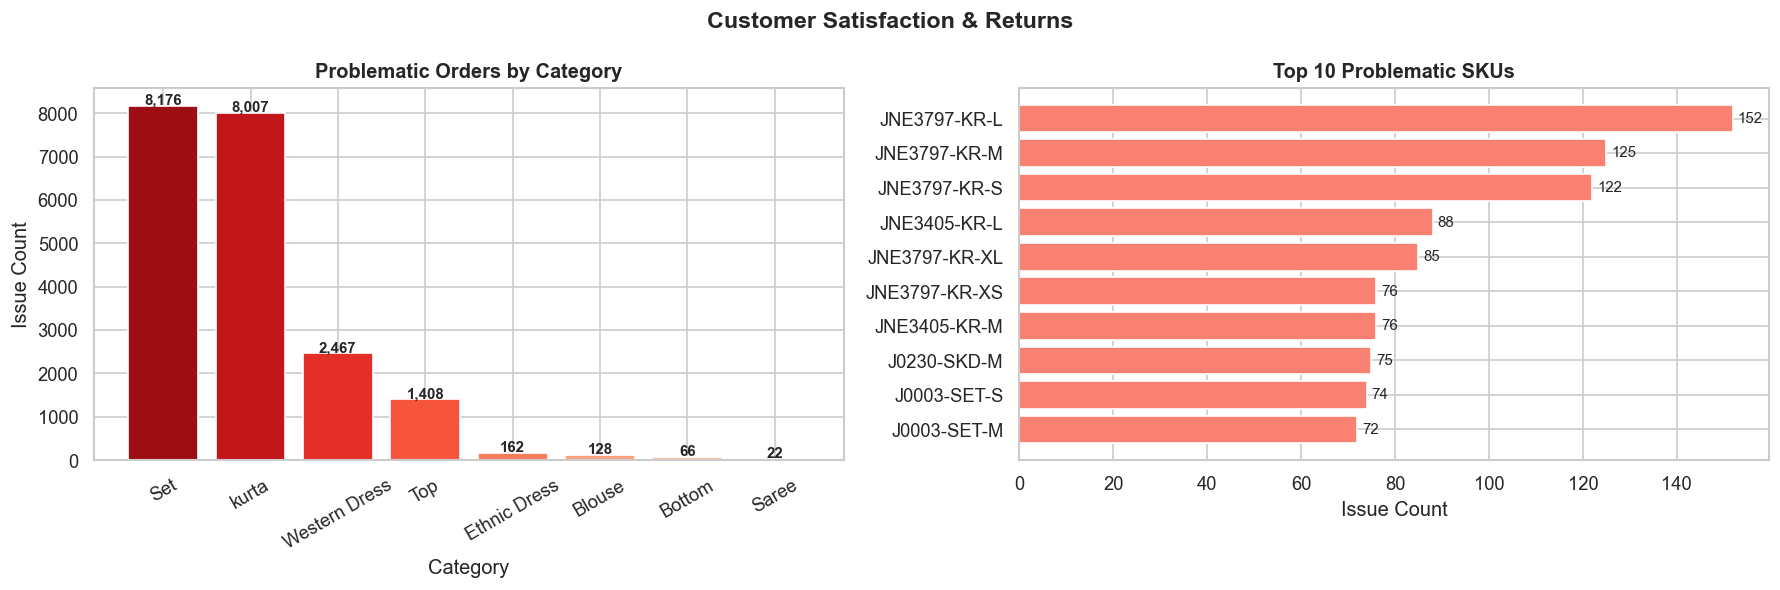

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Problematic by category
axes[0].bar(prob_cat['Category'], prob_cat['Issue_Count'],
            color=sns.color_palette('Reds_r', len(prob_cat)), edgecolor='white')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Problematic Orders by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Issue Count')
axes[0].tick_params(axis='x', rotation=30)

# Top 10 problematic SKUs
axes[1].barh(prob_sku['SKU'], prob_sku['Issue_Count'],
             color='salmon', edgecolor='white')
for bar in axes[1].patches:
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{int(bar.get_width())}', va='center', fontsize=9)
axes[1].invert_yaxis()
axes[1].set_title('Top 10 Problematic SKUs')
axes[1].set_xlabel('Issue Count')

plt.suptitle('Customer Satisfaction & Returns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Conclusion & Recommendations <a id='s6'></a>

---

### Key Findings

| Area | Finding |
|------|---------|
| **Financial** | April was the peak month with highest revenue and orders |
| **Financial** | Sets and Kurtas are the top-selling categories (~76% of orders combined) |
| **Financial** | Sunday drives the highest weekly revenue |
| **Customer** | Maharashtra is the #1 state by order volume |
| **Customer** | April had the highest cancellation count (7,139 orders) |
| **Customer** | B2C dominates volume; B2B has higher average order value |
| **Logistics** | Amazon fulfilment handles ~70% of revenue |
| **Logistics** | 69% of customers prefer Expedited shipping |
| **Product** | M and L sizes have the highest demand |
| **Satisfaction** | Cancellation rate is ~14.2%; Return rate is ~1.5% |
| **Satisfaction** | SKU JNE3797 has the most reported issues |

---

### Recommendations

1. **Investigate April cancellations** — find the root cause (pricing, quality, logistics)
2. **Audit SKU JNE3797** — most problematic product; check quality and size accuracy
3. **Stock M and L sizes more** — highest demand sizes across all categories
4. **Run Sunday campaigns** — highest revenue day; targeted offers could boost sales further
5. **Grow B2B segment** — lower order volume but higher order value; worth a dedicated strategy
6. **Focus marketing on Maharashtra & Karnataka** — top performing states